In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [2]:
file_path = "carrier_hvac_global_v3_enriched.xlsx"

df = pd.read_excel(
    file_path,
    sheet_name="ml_training_dataset"
)

print(df.shape)

df.head()

(18963, 82)


,ml_record_id,dealer_id,product_id,geography_id,prediction_period,dataset_split,target_actual_gm_pct,target_actual_pocket_margin_pct,target_discount_pct_actual,avg_gm_pct_3m,avg_gm_pct_6m,avg_gm_pct_12m,avg_discount_depth_pct,target_achievement_rate_12m,dealer_tier,dealer_tier_enc,dealer_type,annual_units_sold,annual_revenue_usd,premium_product_mix_pct,commercial_project_mix_pct,churn_risk_score,nps_score,contract_type,product_tier,product_tier_enc,product_series,category_l1,category_l2,product_lifecycle_stage,lifecycle_enc,standard_gm_pct,target_gm_pct_product,list_price_usd,landed_cost_usd,capacity_tr,efficiency_rating,wifi_enabled,is_bundle_eligible,days_in_market,inventory_weeks_on_hand,demand_trend_index,is_eol_product,dealer_product_avg_gm_pct_6m,dealer_product_avg_discount_pct,dealer_product_units_sold,country,country_code,region,region_enc,climate_zone,climate_enc,market_density,competitor_avg_price_usd,price_elasticity_index,market_share_pct,demand_index,seasonality_index,cooling_degree_days,market_growth_rate_pct,fiscal_year,fiscal_quarter,fiscal_month,is_peak_season,days_to_quarter_end,is_promo_period,cooling_season_flag,peer_group_id,peer_group_median_gm_pct,peer_group_avg_discount_pct,dealer_vs_peer_gm_delta,negotiated_discount_pct,off_invoice_pct,rebate_pct,coop_fund_pct,freight_pct,warranty_reserve_pct,inventory_weeks_on_hand_curr,units_sold,total_revenue_usd,txn_count,below_floor_count
0,ML-DLR-00001-P-COM-001-2024-12,DLR-00001,P-COM-001,GEO-FRA-PAR,2024-12,Train,0.3881,0.3256,0.0477,0.2830,0.2868,0.288,0.1001,0.4967,Platinum,3,National Distributor,3083,9194759.17,0.4387,0.4154,0.4203,71,Master Dealer,Premium,2,Infinity,Commercial HVAC,Rooftop Unit,Growth,2,0.4703,0.31,18500,10780,20.0,0,1,1,480,11.74,1.4994,0,0.3792,0.0522,1,France,FRA,Europe,0,Temperate,1,Metro,17392.32,1.3599,0.2512,0.9646,1.0367,180,0.0784,2024,4,12,0,30,0,0,PG-001,0.305,0.0619,0.0831,0.0162,0.0625,0.0571,0.0119,0.0112,0.0114,5.99,1,17617.55,1,0
1,ML-DLR-00001-P-COM-001-2025-01,DLR-00001,P-COM-001,GEO-FRA-PAR,2025-01,Train,0.3928,0.2934,0.0404,0.3005,0.2950,0.288,0.1001,0.4967,Platinum,3,National Distributor,3083,9194759.17,0.4387,0.4154,0.4203,71,Master Dealer,Premium,2,Infinity,Commercial HVAC,Rooftop Unit,Growth,2,0.4703,0.31,18500,10780,20.0,0,1,1,480,11.74,1.4994,0,0.3988,0.0365,1,France,FRA,Europe,0,Temperate,1,Metro,17392.32,1.3599,0.2512,0.8823,0.9327,180,0.0638,2025,1,1,0,90,0,0,PG-001,0.305,0.0526,0.0878,0.0250,0.0994,0.0491,0.0194,0.0143,0.0060,5.73,1,17752.60,1,0
2,ML-DLR-00001-P-COM-002-2024-04,DLR-00001,P-COM-002,GEO-FRA-PAR,2024-04,Validation,0.3369,0.2542,0.0976,0.2942,0.2778,0.288,0.1001,0.4967,Platinum,3,National Distributor,3083,9194759.17,0.4387,0.4154,0.4203,71,Master Dealer,Mid-Range,1,Performance,Commercial HVAC,Rooftop Unit,Mature,1,0.4560,0.28,12500,7480,15.0,0,0,1,900,2.25,1.4839,0,0.3315,0.1068,1,France,FRA,Europe,0,Temperate,1,Metro,13074.44,1.6108,0.2527,1.1959,1.3128,180,0.0741,2024,2,4,1,90,1,1,PG-001,0.305,0.0795,0.0319,0.0341,0.0827,0.0231,0.0141,0.0165,0.0047,2.29,1,11280.00,1,0
3,ML-DLR-00001-P-COM-004-2024-12,DLR-00001,P-COM-004,GEO-FRA-PAR,2024-12,Validation,0.3489,0.2524,0.0857,0.3011,0.2958,0.288,0.1001,0.4967,Platinum,3,National Distributor,3083,9194759.17,0.4387,0.4154,0.4203,71,Master Dealer,Premium,2,Infinity,Commercial HVAC,Chiller,Mature,1,0.4588,0.30,85000,50600,100.0,0,1,1,900,10.17,1.1524,0,0.3562,0.0759,1,France,FRA,Europe,0,Temperate,1,Metro,87402.81,1.6586,0.1012,0.8084,0.8856,180,0.1034,2024,4,12,0,30,0,0,PG-001,0.305,0.1011,0.0439,0.0479,0.0965,0.0592,0.0273,0.0072,0.0047,8.74,1,77715.50,1,0
4,ML-DLR-00001-P-COM-004-2025-03,DLR-00001,P-COM-004,GEO-FRA-PAR,2025-03,Train,0.3622,0.2437,0.0667,0.3087,0.2746,0.288,0.1001,0.4967,Platinum,3,National Distributor,3083,9194759.17,0.4387,0.4154,0.4203,71,Master Dealer,Premium,2,Infinity,Commercial HVAC,Chiller,Mature,1,0.4588,0.30,85000,50600,100.0,0,1,1,900,10.17,1.1524,0,0.3534,0.0659,1,France,FRA,Europe,0,Temperate,1,Metro,87402.81,1.6586,0.1012,

In [3]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18963 entries, 0 to 18962
Data columns (total 82 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   ml_record_id                     18963 non-null  object 
 1   dealer_id                        18963 non-null  object 
 2   product_id                       18963 non-null  object 
 3   geography_id                     18963 non-null  object 
 4   prediction_period                18963 non-null  object 
 5   dataset_split                    18963 non-null  object 
 6   target_actual_gm_pct             18963 non-null  float64
 7   target_actual_pocket_margin_pct  18963 non-null  float64
 8   target_discount_pct_actual       18963 non-null  float64
 9   avg_gm_pct_3m                    18963 non-null  float64
 10  avg_gm_pct_6m                    18963 non-null  float64
 11  avg_gm_pct_12m                   18963 non-null  float64
 12  avg_discount_depth

In [4]:
df.describe().T.head(20)

,count,mean,std,min,25%,50%,75%,max
target_actual_gm_pct,18963.0,3.712035e-01,6.860024e-02,0.0891,0.3422,3.832000e-01,4.188000e-01,5.141000e-01
target_actual_pocket_margin_pct,18963.0,2.962147e-01,6.811725e-02,0.0117,0.2668,3.086000e-01,3.421000e-01,4.679000e-01
target_discount_pct_actual,18963.0,1.039475e-01,6.062733e-02,0.0000,0.0627,9.400000e-02,1.323000e-01,3.405000e-01
avg_gm_pct_3m,18963.0,2.421309e-01,3.482293e-02,0.1352,0.2165,2.389000e-01,2.669500e-01,3.372000e-01
avg_gm_pct_6m,18963.0,2.421915e-01,3.382227e-02,0.1411,0.2172,2.394000e-01,2.662000e-01,3.310000e-01
avg_gm_pct_12m,18963.0,2.422952e-01,3.257587e-02,0.1570,0.2155,2.367000e-01,2.649000e-01,3.152000e-01
avg_discount_depth_pct,18963.0,1.018431e-01,3.764423e-02,0.0352,0.0696,9.850000e-02,1.334000e-01,1.707000e-01
target_achievement_rate_12m,18963.0,5.894779e-01,1.672533e-01,0.3038,0.4411,5.935000e-01,7.336000e-01,8.965000e-01
dealer_tier_enc,18963.0,1.387333e+00,8.195493e-01,0.0000,1.0000,1.000000e+00,2.000000e+00,3.000000e+00
annual_units_sold,18963.0,6.670257e+02,9.409399e+02,14.0000,196.0000,3.100000e+02,7.670000e+02,3.953000e+03


In [5]:
missing = (
    df.isnull()
      .sum()
      .sort_values(ascending=False)
)

missing[missing > 0].head(30)

Series([], dtype: int64)

In [6]:
print(df["target_actual_gm_pct"].describe())

count    18963.000000
mean         0.371204
std          0.068600
min          0.089100
25%          0.342200
50%          0.383200
75%          0.418800
max          0.514100
Name: target_actual_gm_pct, dtype: float64


In [7]:
target_corr = (
    df.select_dtypes(include=["int64","float64"])
      .corr(numeric_only=True)["target_actual_gm_pct"]
      .sort_values(ascending=False)
)

print(target_corr.head(25))

target_actual_gm_pct               1.000000
dealer_product_avg_gm_pct_6m       0.992102
target_actual_pocket_margin_pct    0.968113
dealer_vs_peer_gm_delta            0.898745
target_gm_pct_product              0.826608
product_tier_enc                   0.809562
standard_gm_pct                    0.802537
lifecycle_enc                      0.678243
wifi_enabled                       0.615204
is_bundle_eligible                 0.565549
is_promo_period                    0.155375
cooling_season_flag                0.155375
is_peak_season                     0.155375
off_invoice_pct                    0.153741
inventory_weeks_on_hand            0.145032
seasonality_index                  0.110494
demand_index                       0.107040
market_share_pct                   0.049873
dealer_tier_enc                    0.043466
peer_group_median_gm_pct           0.043063
annual_revenue_usd                 0.037027
avg_gm_pct_12m                     0.036386
avg_gm_pct_6m                   

In [8]:
print(
    df["dataset_split"]
    .value_counts()
)

dataset_split
Train         13840
Validation     3072
Test           2051
Name: count, dtype: int64


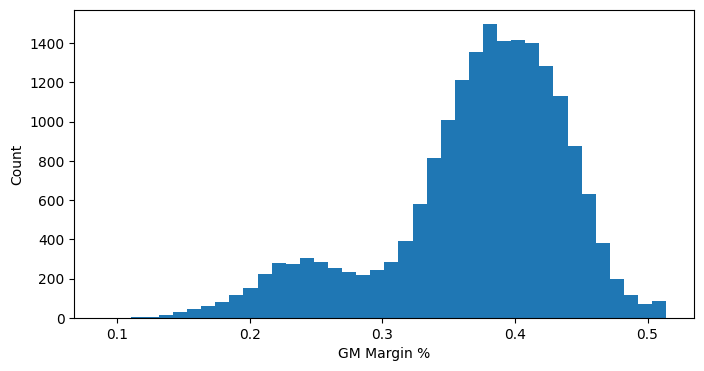

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))

plt.hist(
    df["target_actual_gm_pct"],
    bins=40
)

plt.xlabel("GM Margin %")
plt.ylabel("Count")

plt.show()

In [10]:
leakage_cols = [

    # identifiers
    "ml_record_id",
    "dealer_id",
    "product_id",
    "geography_id",

    # target / direct leakage
    "target_actual_pocket_margin_pct",
    "target_discount_pct_actual",

    # extremely suspicious
    "dealer_product_avg_gm_pct_6m",
    "dealer_vs_peer_gm_delta",

    # target-derived / future info
    "target_gm_pct_product",

    # likely post-event metrics
    "total_revenue_usd",
    "units_sold",
    "below_floor_count",

]

In [11]:
df_model = df.drop(
    columns=leakage_cols,
    errors="ignore"
)

print(df_model.shape)

(18963, 70)


In [12]:
TARGET = "target_actual_gm_pct"

X = df_model.drop(columns=[TARGET])

y = df_model[TARGET]

print(X.shape)
print(y.shape)

(18963, 69)
(18963,)


In [13]:
train_mask = df_model["dataset_split"]=="Train"
val_mask   = df_model["dataset_split"]=="Validation"
test_mask  = df_model["dataset_split"]=="Test"

X_train = X[train_mask].drop(columns=["dataset_split"])
y_train = y[train_mask]

X_val = X[val_mask].drop(columns=["dataset_split"])
y_val = y[val_mask]

X_test = X[test_mask].drop(columns=["dataset_split"])
y_test = y[test_mask]

print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

(13840, 68)
(3072, 68)
(2051, 68)


In [14]:
categorical_cols = X_train.select_dtypes(
    include=["object"]
).columns.tolist()

print(categorical_cols)

print()

print("count =",len(categorical_cols))

['prediction_period', 'dealer_tier', 'dealer_type', 'contract_type', 'product_tier', 'product_series', 'category_l1', 'category_l2', 'product_lifecycle_stage', 'country', 'country_code', 'region', 'climate_zone', 'market_density', 'peer_group_id']

count = 15


In [15]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

categorical_cols = X_train.select_dtypes(
    include=["object"]
).columns.tolist()

numeric_cols = X_train.select_dtypes(
    exclude=["object"]
).columns.tolist()

print("categorical:",len(categorical_cols))
print("numeric:",len(numeric_cols))

categorical: 15
numeric: 53


In [16]:
preprocessor = ColumnTransformer(

    transformers=[

        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_cols
        ),

        (
            "num",
            "passthrough",
            numeric_cols
        )

    ]

)

In [17]:
X_train_processed = preprocessor.fit_transform(X_train)

X_val_processed = preprocessor.transform(X_val)

X_test_processed = preprocessor.transform(X_test)

print(X_train_processed.shape)
print(X_val_processed.shape)
print(X_test_processed.shape)

(13840, 266)
(3072, 266)
(2051, 266)


In [18]:
feature_names = preprocessor.get_feature_names_out()

print("Total Features:",len(feature_names))

print(feature_names[:20])

Total Features: 266
['cat__prediction_period_2024-01' 'cat__prediction_period_2024-02'
 'cat__prediction_period_2024-03' 'cat__prediction_period_2024-04'
 'cat__prediction_period_2024-05' 'cat__prediction_period_2024-06'
 'cat__prediction_period_2024-07' 'cat__prediction_period_2024-08'
 'cat__prediction_period_2024-09' 'cat__prediction_period_2024-10'
 'cat__prediction_period_2024-11' 'cat__prediction_period_2024-12'
 'cat__prediction_period_2025-01' 'cat__prediction_period_2025-02'
 'cat__prediction_period_2025-03' 'cat__prediction_period_2025-04'
 'cat__prediction_period_2025-05' 'cat__prediction_period_2025-06'
 'cat__prediction_period_2025-07' 'cat__prediction_period_2025-08']


In [30]:
print(type(X_train_processed))
print(X_train_processed.shape)

<class 'scipy.sparse._csr.csr_matrix'>
(13840, 266)


In [31]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100,max_depth=10,min_samples_leaf=5,min_samples_split=10,random_state=42,n_jobs=-1)

rf.fit(X_train_processed,y_train)

RandomForestRegressor(max_depth=10, min_samples_leaf=5, min_samples_split=10,
                      n_jobs=-1, random_state=42)

In [32]:
val_pred = rf.predict(X_val_processed)

In [33]:
from sklearn.metrics import (mean_absolute_error,mean_squared_error,r2_score)

mae = mean_absolute_error(y_val,val_pred)

rmse = np.sqrt(mean_squared_error(y_val,val_pred))

r2 = r2_score(y_val,val_pred)

print("MAE :",mae)
print("RMSE:",rmse)
print("R2  :",r2)

MAE : 0.0037259503820193797
RMSE: 0.004776650318416071
R2  : 0.9949825150957531


In [34]:
train_pred = rf.predict(X_train_processed)

train_r2 = r2_score(y_train,train_pred)

print("Train R2:",train_r2)

Train R2: 0.9969083794545426


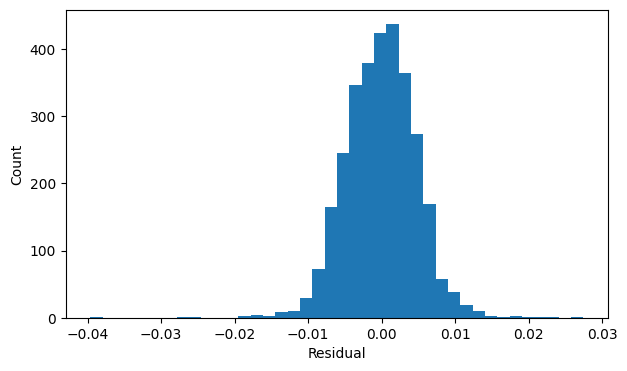

In [35]:
import matplotlib.pyplot as plt

residuals = y_val - val_pred

plt.figure(figsize=(7,4))

plt.hist(residuals,bins=40)

plt.xlabel("Residual")

plt.ylabel("Count")

plt.show()

In [36]:
import pandas as pd

importance_df = pd.DataFrame({"feature": feature_names,"importance": rf.feature_importances_})

importance_df = importance_df.sort_values("importance",ascending=False)

importance_df.head(20)

,feature,importance
225,num__product_tier_enc,0.366398
227,num__standard_gm_pct,0.222306
238,num__dealer_product_avg_discount_pct,0.201027
46,cat__product_tier_Economy,0.116299
49,cat__product_series_GoodValue,0.085327
258,num__negotiated_discount_pct,0.001570
242,num__competitor_avg_price_usd,0.001149
229,num__landed_cost_usd,0.001125
228,num__list_price_usd,0.000980
231,num__efficiency_rating,0.000792


In [37]:
from sklearn.ensemble import RandomForestRegressor

rf_small = RandomForestRegressor(

    n_estimators=30,
    max_depth=5,

    random_state=42,
    n_jobs=-1

)

rf_small.fit(
    X_train_processed,
    y_train
)

pred_small = rf_small.predict(
    X_val_processed
)

print(
    r2_score(
        y_val,
        pred_small
    )
)

0.968030893631346


In [38]:
remove_more = [

    "standard_gm_pct",

    "product_tier_enc",

    "product_tier",

    "product_series",

    "dealer_product_avg_discount_pct"

]

X_train2 = X_train.drop(
    columns=remove_more,
    errors="ignore"
)

X_val2 = X_val.drop(
    columns=remove_more,
    errors="ignore"
)

X_test2 = X_test.drop(
    columns=remove_more,
    errors="ignore"
)

In [39]:
categorical_cols2 = X_train2.select_dtypes(
    include=["object"]
).columns.tolist()

numeric_cols2 = X_train2.select_dtypes(
    exclude=["object"]
).columns.tolist()

In [40]:
preprocessor2 = ColumnTransformer(

    transformers=[

        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_cols2
        ),

        (
            "num",
            "passthrough",
            numeric_cols2
        )

    ]

)

In [41]:
X_train2_p = preprocessor2.fit_transform(
    X_train2
)

X_val2_p = preprocessor2.transform(
    X_val2
)

In [42]:
rf2 = RandomForestRegressor(

    n_estimators=100,

    max_depth=10,

    min_samples_leaf=5,

    min_samples_split=10,

    random_state=42,

    n_jobs=-1

)

rf2.fit(
    X_train2_p,
    y_train
)

pred2 = rf2.predict(
    X_val2_p
)

print(
    "R2:",
    r2_score(
        y_val,
        pred2
    )
)

print(
    "RMSE:",
    np.sqrt(
        mean_squared_error(
            y_val,
            pred2
        )
    )
)

R2: 0.948489361585525
RMSE: 0.015304842978546914


In [43]:
!pip install xgboost


[notice] A new release of pip is available: 24.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [44]:
from xgboost import XGBRegressor

xgb = XGBRegressor(

    n_estimators=300,

    learning_rate=0.05,

    max_depth=6,

    subsample=0.8,

    colsample_bytree=0.8,

    objective="reg:squarederror",

    random_state=42,

    n_jobs=-1
)

xgb.fit(

    X_train2_p,

    y_train,

    eval_set=[

        (X_train2_p,y_train),

        (X_val2_p,y_val)

    ],

    verbose=False
)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=-1, num_parallel_tree=None, ...)

In [45]:
xgb_pred = xgb.predict(
    X_val2_p
)

print(
    "R2:",
    r2_score(
        y_val,
        xgb_pred
    )
)

print(
    "RMSE:",
    np.sqrt(
        mean_squared_error(
            y_val,
            xgb_pred
        )
    )
)

print(
    "MAE:",
    mean_absolute_error(
        y_val,
        xgb_pred
    )
)

R2: 0.9513159578159327
RMSE: 0.014878999427391692
MAE: 0.010914144514353635


In [46]:
train_pred_xgb = xgb.predict(
    X_train2_p
)

print(

    "Train R2:",

    r2_score(
        y_train,
        train_pred_xgb
    )
)

Train R2: 0.9780716475038328


In [47]:
from xgboost import XGBRegressor

xgb_tuned = XGBRegressor(

    n_estimators=600,

    learning_rate=0.03,

    max_depth=5,

    subsample=0.85,

    colsample_bytree=0.85,

    min_child_weight=3,

    reg_alpha=0.1,

    reg_lambda=1.5,

    objective="reg:squarederror",

    random_state=42,

    n_jobs=-1

)

xgb_tuned.fit(

    X_train2_p,

    y_train,

    eval_set=[

        (X_val2_p,y_val)

    ],

    verbose=False
)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.85, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.03, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=3, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=600,
             n_jobs=-1, num_parallel_tree=None, ...)

In [48]:
pred_tuned = xgb_tuned.predict(
    X_val2_p
)

print(
    "R2:",
    r2_score(
        y_val,
        pred_tuned
    )
)

print(
    "RMSE:",
    np.sqrt(
        mean_squared_error(
            y_val,
            pred_tuned
        )
    )
)

print(
    "MAE:",
    mean_absolute_error(
        y_val,
        pred_tuned
    )
)

R2: 0.951590948170434
RMSE: 0.014836918128133434
MAE: 0.010864126724144442


In [49]:
X_test2_p = preprocessor2.transform(X_test2)

In [50]:
test_pred = xgb_tuned.predict(X_test2_p)

In [51]:
print(
    "TEST R2:",
    r2_score(
        y_test,
        test_pred
    )
)

print(
    "TEST RMSE:",
    np.sqrt(
        mean_squared_error(
            y_test,
            test_pred
        )
    )
)

print(
    "TEST MAE:",
    mean_absolute_error(
        y_test,
        test_pred
    )
)

TEST R2: 0.9527029350653096
TEST RMSE: 0.014589284750946547
TEST MAE: 0.010648238389297907


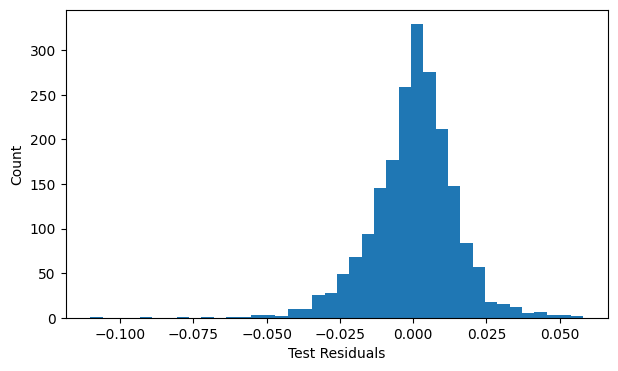

In [52]:
residuals_test = y_test - test_pred

plt.figure(figsize=(7,4))

plt.hist(
    residuals_test,
    bins=40
)

plt.xlabel("Test Residuals")

plt.ylabel("Count")

plt.show()

In [53]:
import joblib

joblib.dump(
    preprocessor2,
    "gm_margin_preprocessor.pkl"
)

joblib.dump(
    xgb_tuned,
    "gm_margin_xgboost.pkl"
)

print("saved")

saved


In [56]:
importance = pd.DataFrame({

    "feature":
    preprocessor2.get_feature_names_out(),

    "importance":
    xgb_tuned.feature_importances_

})

importance.sort_values(
    "importance",
    ascending=False
).head(20)

,feature,importance
76,cat__product_lifecycle_stage_EOL,0.527384
223,num__wifi_enabled,0.190251
218,num__lifecycle_enc,0.151375
78,cat__product_lifecycle_stage_Launch,0.014078
248,num__negotiated_discount_pct,0.011563
220,num__landed_cost_usd,0.011302
219,num__list_price_usd,0.010622
232,num__competitor_avg_price_usd,0.008556
55,cat__category_l2_Air Monitor,0.005214
242,num__is_peak_season,0.004555


In [57]:
remove_lifecycle = [

    "product_lifecycle_stage",
    "lifecycle_enc"

]

X_train3 = X_train2.drop(
    columns=remove_lifecycle,
    errors="ignore"
)

X_val3 = X_val2.drop(
    columns=remove_lifecycle,
    errors="ignore"
)

X_test3 = X_test2.drop(
    columns=remove_lifecycle,
    errors="ignore"
)

In [58]:
categorical_cols3 = X_train3.select_dtypes(
    include=["object"]
).columns.tolist()

numeric_cols3 = X_train3.select_dtypes(
    exclude=["object"]
).columns.tolist()

In [59]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor3 = ColumnTransformer(

    transformers=[

        (

            "cat",

            OneHotEncoder(
                handle_unknown="ignore"
            ),

            categorical_cols3

        ),

        (

            "num",

            "passthrough",

            numeric_cols3

        )

    ]

)

In [60]:
X_train3_p = preprocessor3.fit_transform(
    X_train3
)

X_val3_p = preprocessor3.transform(
    X_val3
)

X_test3_p = preprocessor3.transform(
    X_test3
)

In [61]:
from xgboost import XGBRegressor

xgb_ablation = XGBRegressor(

    n_estimators=600,

    learning_rate=0.03,

    max_depth=5,

    subsample=0.85,

    colsample_bytree=0.85,

    min_child_weight=3,

    reg_alpha=0.1,

    reg_lambda=1.5,

    objective="reg:squarederror",

    random_state=42,

    n_jobs=-1

)

xgb_ablation.fit(

    X_train3_p,

    y_train,

    verbose=False
)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.85, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.03, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=3, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=600,
             n_jobs=-1, num_parallel_tree=None, ...)

In [62]:
pred_ablation = xgb_ablation.predict(
    X_val3_p
)

print(
    "R2:",
    r2_score(
        y_val,
        pred_ablation
    )
)

print(
    "RMSE:",
    np.sqrt(
        mean_squared_error(
            y_val,
            pred_ablation
        )
    )
)

print(
    "MAE:",
    mean_absolute_error(
        y_val,
        pred_ablation
    )
)

R2: 0.9516732176047539
RMSE: 0.014824305364007686
MAE: 0.010858723806046569


In [63]:
import joblib

joblib.dump(

    preprocessor3,

    "gm_margin_preprocessor_final.pkl"

)

joblib.dump(

    xgb_ablation,

    "gm_margin_xgb_final.pkl"

)

print("FINAL MODEL SAVED")

FINAL MODEL SAVED


In [64]:
final_features = X_train3.columns.tolist()

joblib.dump(

    final_features,

    "gm_margin_feature_order.pkl"

)

print(len(final_features))

61


In [65]:
### INFERENCE PIPELINE 

# import joblib
# import pandas as pd

# preprocessor = joblib.load(
#     "gm_margin_preprocessor_final.pkl"
# )

# model = joblib.load(
#     "gm_margin_xgb_final.pkl"
# )

# features = joblib.load(
#     "gm_margin_feature_order.pkl"
# )

# new_df = new_df[features]

# new_processed = preprocessor.transform(
#     new_df
# )

# pred = model.predict(
#     new_processed
# )

# print(pred)